# VAE Optical Glass Dataset Generation

This notebook ingests the standard optical glass database from `catalog_nk.csv` (available through Optiland repo) and filters for physically valid glasses in the visible spectrum. For each valid glass, we compute its refractive index profile across a grid of $N = 128$ wavelengths over the extended visible spectrum ($0.380\ \mu\text{m}$ to $0.780\ \mu\text{m}$).

The output of this notebook is:
1. `glasses_metadata.csv`: A CSV file containing metadata for each valid glass (e.g., name, catalog/group, $n_d$, $V_d$, $P_{g,F}$, and anomalous deviation $dPgF$).
2. `glasses_refractive_indices.npy`: A 2D numpy array of shape `(num_glasses, 128)` containing the refractive index values across the 128 wavelengths.

This generated dataset is designed specifically for training a Generative Model, such as a **Variational Autoencoder (VAE)**, to learn a low-dimensional latent representation of realistic optical glass dispersion curves.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from optiland.materials import MaterialFile

In [ ]:
def find_workspace_root() -> str:
    """Finds the workspace root directory containing the database.

    Returns:
        str: Absolute path to the workspace root directory.
    """
    curr = os.path.abspath('.')
    while True:
        target = os.path.join(curr, 'optiland', 'database', 'catalog_nk.csv')
        if os.path.exists(target):
            return curr
        parent = os.path.dirname(curr)
        if parent == curr:
            fallback = r'c:\optiland'  # set to cloned optiland location
            if os.path.exists(fallback):
                return fallback
            raise FileNotFoundError("Could not find optiland workspace root.")
        curr = parent

# Resolve canonical paths
ROOT_DIR = find_workspace_root()
CATALOG_PATH = os.path.join(ROOT_DIR, 'optiland', 'database', 'catalog_nk.csv')
DATA_DIR = os.path.join(ROOT_DIR, 'optiland', 'database', 'data-nk')

In [3]:
# Definition of constants and spectral grid
VALID_CATALOGS = ['schott', 'ohara', 'hoya', 'cdgm', 'sumita', 'hikari']

# Spectral Grid parameters (N = 100 wavelengths in microns)
N_WAVELENGTHS = 128
WAVE_GRID = np.linspace(0.380, 0.780, N_WAVELENGTHS)

# Standard reference wavelengths (in microns)
WAVE_D = 0.5875618  # d-line (yellow Helium)
WAVE_F = 0.4861327  # F-line (blue Hydrogen)
WAVE_C = 0.6562725  # C-line (red Hydrogen)
WAVE_g = 0.4358343  # g-line (blue-violet Mercury)

In [4]:
def load_standard_glasses(
    catalog_path: str = CATALOG_PATH,
    wave_grid: np.ndarray = WAVE_GRID
) -> pd.DataFrame:
    """Loads and filters physically standard visible spectrum glasses.

    Args:
        catalog_path: Path to the catalog_nk.csv database file.
        wave_grid: Spectral grid of wavelengths to evaluate.

    Returns:
        pd.DataFrame: DataFrame of valid glasses and their dispersion curves.
    """
    if not os.path.exists(catalog_path):
        raise FileNotFoundError(f"Catalog file not found at: {catalog_path}")

    df_raw = pd.read_csv(catalog_path)
    valid_data = []

    # Physical boundary constraints for standard optical glasses
    ND_MIN, ND_MAX = 1.35, 2.6
    VD_MIN, VD_MAX = 15.0, 100.0

    for idx, row in df_raw.iterrows():
        # Filter catalogs to standard manufacturers
        f_name = str(row.get('filename', '')).lower()
        g_name = str(row.get('group', '')).lower()
        identifier = f_name + g_name

        is_valid_catalog = any(c in identifier for c in VALID_CATALOGS)
        if not is_valid_catalog:
            continue

        filepath = os.path.join(DATA_DIR, row['filename'])
        if not os.path.exists(filepath):
            continue

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                mat = MaterialFile(filepath)

                # Reference index values
                nd = mat.n(WAVE_D).item()
                nF = mat.n(WAVE_F).item()
                nC = mat.n(WAVE_C).item()
                ng = mat.n(WAVE_g).item()

            # Filter out non-physical index values
            if np.isnan(nd) or nd <= 1.0:
                continue

            dispersion = nF - nC
            if dispersion <= 1e-9:
                continue

            # Compute Abbe number (Vd)
            Vd = (nd - 1.0) / dispersion

            # Apply standard glass range filters
            if not (ND_MIN < nd < ND_MAX):
                continue
            if not (VD_MIN < Vd < VD_MAX):
                continue

            # Generate full visible spectrum curve
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                curve = mat.n(wave_grid)

            # Filter out any curves with NaN values
            if np.any(np.isnan(curve)):
                continue

            # Compute relative partial dispersion (PgF) and deviation (dPgF)
            PgF = (ng - nF) / (nF - nC)
            PgF_normal = 0.6438 - 0.001682 * Vd
            dPgF = PgF - PgF_normal

            valid_data.append({
                'name': row['name'],
                'catalog': row['group'],
                'nd': nd,
                'Vd': Vd,
                'PgF': PgF,
                'dPgF': dPgF,
                'curve': curve
            })

        except Exception:
            continue

    return pd.DataFrame(valid_data)

In [5]:
print("Ingesting glass database and filtering valid standard glasses...")
df_glasses = load_standard_glasses()
print(f"Ingestion complete! Total valid glasses loaded: {len(df_glasses)}")

Ingesting glass database and filtering valid standard glasses...
Ingestion complete! Total valid glasses loaded: 1678


## Process and Save the Dataset

Now we split the loaded dataset into:
1. **Metadata DataFrame**: Contains descriptive attributes for each glass, which is saved as `glasses_metadata.csv` (excluding the 1D curve data).
2. **2D Dispersion Matrix**: Stacks the individual 1D refractive index curves to produce a single 2D matrix of shape `(num_glasses, 100)`. This matrix is saved as `glasses_refractive_indices.npy` for efficient VAE training inputs.

In [6]:
# 1. Limit Vd range to between 20 and 95 for later VAE training
valid = (df_glasses.Vd > 20) & (df_glasses.Vd < 95)
df_glasses = df_glasses[valid]

# 2. Process and save the metadata DataFrame
df_metadata = df_glasses.drop(columns=['curve'])
metadata_path = os.path.join(ROOT_DIR, 'glasses_metadata.csv')
df_metadata.to_csv(metadata_path, index=False)
print(f"Metadata saved successfully.")
print(df_metadata.head())

# 3. Extract and stack the 2D matrix of refractive indices
refractive_indices = np.vstack(df_glasses['curve'].values)
indices_path = os.path.join(ROOT_DIR, 'glasses_refractive_indices.npy')
np.save(indices_path, refractive_indices)
print(f"\nRefractive indices 2D matrix saved successfully.")
print(f"2D Matrix Shape: {refractive_indices.shape}")

Metadata saved successfully.
              name catalog        nd         Vd       PgF      dPgF
0   N-BK7 (SCHOTT)   glass  1.516800  64.167336  0.534930 -0.000940
1   S-BSL7 (OHARA)   glass  1.516330  64.142022  0.535285 -0.000628
2  J-BK7A (HIKARI)   glass  1.516800  64.129950  0.535641 -0.000292
3     H-K9L (CDGM)   glass  1.516800  64.198732  0.535828  0.000011
4      BSC7 (HOYA)   glass  1.516798  64.198258  0.534281 -0.001538

Refractive indices 2D matrix saved successfully.
2D Matrix Shape: (1648, 128)


## Visual Audit of the Generated Dataset

To ensure correct and clean generation, we perform a visual audit by plotting the dispersion curves of several random glasses across the visible spectral grid.

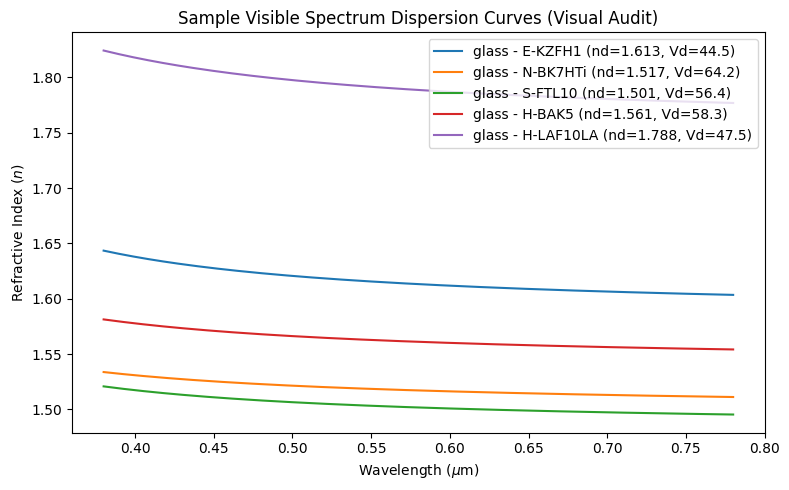

In [7]:
# Select random glass indices for visualization
np.random.seed(67)
random_indices = np.random.choice(len(df_glasses), size=5, replace=False)

plt.figure(figsize=(8, 5))
for idx in random_indices:
    row = df_glasses.iloc[idx]
    plt.plot(WAVE_GRID, row['curve'], label=f"{row['catalog']} - {row['name']} (nd={row['nd']:.3f}, Vd={row['Vd']:.1f})")

plt.xlabel(r"Wavelength ($\mu$m)")
plt.ylabel("Refractive Index ($n$)")
plt.title("Sample Visible Spectrum Dispersion Curves (Visual Audit)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()